# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Clinical Trial Phase Dataset](https://www.kaggle.com/datasets/sergionefedov/what-predicts-a-phase-3-trials-success?select=clinical_trial_phase3_success.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

/kaggle/input/datasets/sergionefedov/what-predicts-a-phase-3-trials-success/data_dictionary_clinical_trial.csv
/kaggle/input/datasets/sergionefedov/what-predicts-a-phase-3-trials-success/clinical_trial_phase3_success.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('clinical_trial_phase3_success.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,trial_id,therapeutic_area,uses_biomarker,phase2_effect_size,phase2_pvalue_strength,endpoint_type,enrollment,statistical_power,sponsor_type,novel_mechanism,prior_approvals_target,randomized,double_blind,active_comparator,years_in_development,orphan_designation,trial_success
0,TRL000000,oncology,0,4.50,8.57,clinical,884,0.804,academic,1,1,1,0,1,5.5,0,1
1,TRL000001,cns,1,3.13,8.05,hard_survival,2004,0.821,mid_pharma,1,1,1,1,1,7.9,0,0
2,TRL000002,cardiovascular,0,4.08,4.69,hard_survival,379,0.844,small_biotech,0,0,1,1,0,8.2,0,0
3,TRL000003,vaccine,0,4.69,7.20,surrogate,1019,0.914,academic,0,2,0,0,1,8.7,1,0
4,TRL000004,oncology,0,3.88,10.00,hard_survival,268,0.685,small_biotech,1,1,0,1,1,7.8,0,0


## last Five row

In [4]:
df.tail()

,trial_id,therapeutic_area,uses_biomarker,phase2_effect_size,phase2_pvalue_strength,endpoint_type,enrollment,statistical_power,sponsor_type,novel_mechanism,prior_approvals_target,randomized,double_blind,active_comparator,years_in_development,orphan_designation,trial_success
41995,TRL041995,oncology,0,5.55,6.36,hard_survival,1158,0.844,small_biotech,1,0,1,1,0,8.7,0,0
41996,TRL041996,cns,1,3.21,8.27,surrogate,331,0.862,large_pharma,0,2,1,1,0,8.2,0,1
41997,TRL041997,cns,0,6.60,8.14,clinical,594,0.894,mid_pharma,0,1,0,1,1,5.8,0,0
41998,TRL041998,cardiovascular,0,4.10,10.00,clinical,372,0.948,small_biotech,1,2,1,0,0,9.3,0,1
41999,TRL041999,oncology,1,3.61,7.76,clinical,953,0.816,mid_pharma,1,1,0,1,1,5.1,1,1


## Shape of our dataset

In [5]:
df.shape

(42000, 17)

## List out all columns

In [6]:
df.columns

Index(['trial_id', 'therapeutic_area', 'uses_biomarker', 'phase2_effect_size',
       'phase2_pvalue_strength', 'endpoint_type', 'enrollment',
       'statistical_power', 'sponsor_type', 'novel_mechanism',
       'prior_approvals_target', 'randomized', 'double_blind',
       'active_comparator', 'years_in_development', 'orphan_designation',
       'trial_success'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

trial_id                   object
therapeutic_area           object
uses_biomarker              int64
phase2_effect_size        float64
phase2_pvalue_strength    float64
endpoint_type              object
enrollment                  int64
statistical_power         float64
sponsor_type               object
novel_mechanism             int64
prior_approvals_target      int64
randomized                  int64
double_blind                int64
active_comparator           int64
years_in_development      float64
orphan_designation          int64
trial_success               int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   trial_id                42000 non-null  object 
 1   therapeutic_area        42000 non-null  object 
 2   uses_biomarker          42000 non-null  int64  
 3   phase2_effect_size      42000 non-null  float64
 4   phase2_pvalue_strength  42000 non-null  float64
 5   endpoint_type           42000 non-null  object 
 6   enrollment              42000 non-null  int64  
 7   statistical_power       42000 non-null  float64
 8   sponsor_type            42000 non-null  object 
 9   novel_mechanism         42000 non-null  int64  
 10  prior_approvals_target  42000 non-null  int64  
 11  randomized              42000 non-null  int64  
 12  double_blind            42000 non-null  int64  
 13  active_comparator       42000 non-null  int64  
 14  years_in_development    42000 non-null

## Check Null Value

In [9]:
df.isnull().sum()

trial_id                  0
therapeutic_area          0
uses_biomarker            0
phase2_effect_size        0
phase2_pvalue_strength    0
endpoint_type             0
enrollment                0
statistical_power         0
sponsor_type              0
novel_mechanism           0
prior_approvals_target    0
randomized                0
double_blind              0
active_comparator         0
years_in_development      0
orphan_designation        0
trial_success             0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,uses_biomarker,phase2_effect_size,phase2_pvalue_strength,enrollment,statistical_power,novel_mechanism,prior_approvals_target,randomized,double_blind,active_comparator,years_in_development,orphan_designation,trial_success
count,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000,42000.000000
mean,0.416929,4.995196,6.911676,601.287024,0.816848,0.418310,1.199738,0.880286,0.719952,0.494952,6.994219,0.180548,0.550333
std,0.493057,1.975686,2.013064,422.738480,0.097188,0.493287,1.100072,0.324631,0.449028,0.499980,2.496013,0.384647,0.497466
min,0.000000,0.000000,0.000000,40.000000,0.401000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.000000,3.640000,5.540000,290.000000,0.750000,0.000000,0.000000,1.000000,0.000000,0.000000,5.300000,0.000000,0.000000
50%,0.000000,4.990000,6.980000,504.000000,0.819000,0.000000,1.000000,1.000000,1.000000,0.000000,7.000000,0.000000,1.000000
75%,1.000000,6.330000,8.440000,811.000000,0.887000,1.000000,2.000000,1.000000,1.000000,1.000000,8.700000,0.000000,1.000000
max,1.000000,10.000000,10.000000,4194.000000,0.990000,1.000000,9.000000,1.000000,1.000000,1.000000,17.000000,1.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

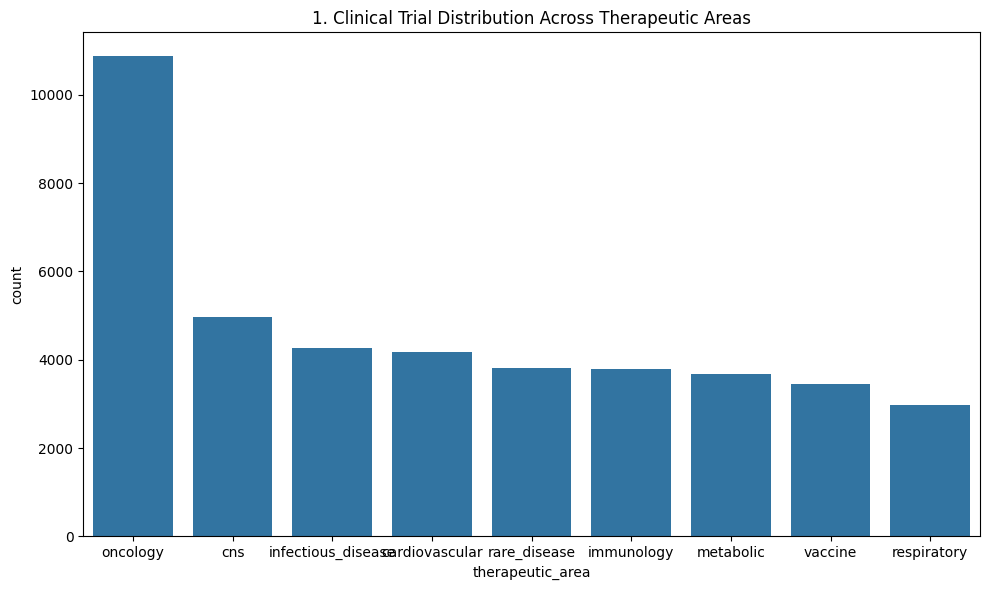

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='therapeutic_area', order=df['therapeutic_area'].value_counts().index)
plt.title(f'{plot_no}. Clinical Trial Distribution Across Therapeutic Areas')
show_fig()
plot_no += 1

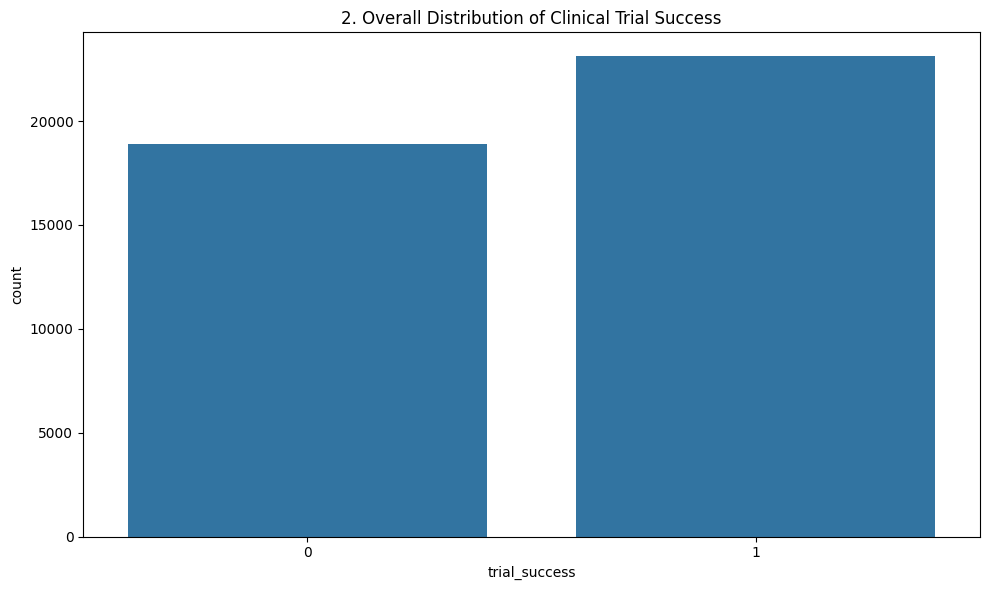

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='trial_success')
plt.title(f'{plot_no}. Overall Distribution of Clinical Trial Success')
show_fig()
plot_no += 1

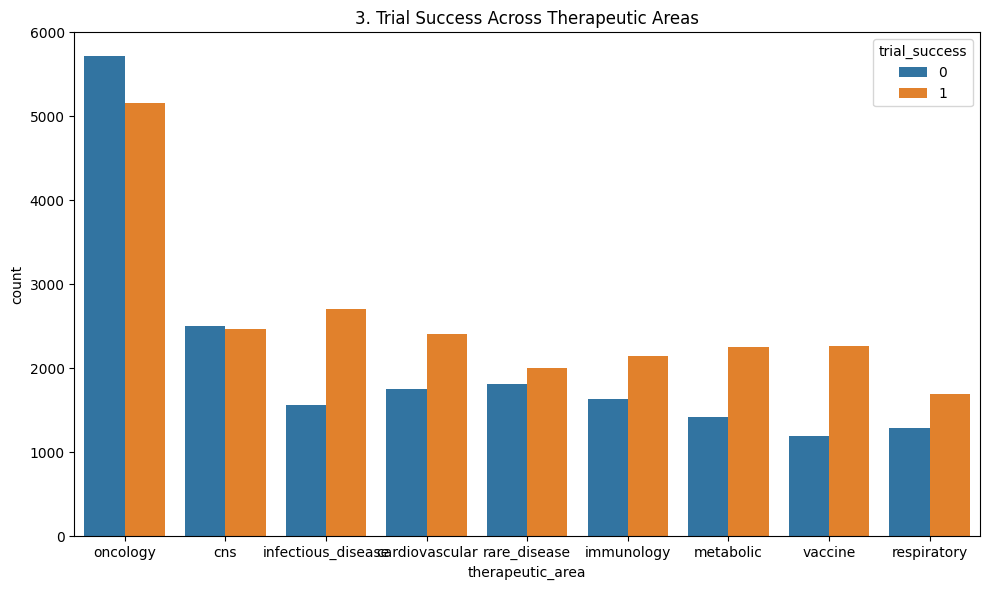

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='therapeutic_area', hue='trial_success', order=df['therapeutic_area'].value_counts().index)
plt.title(f'{plot_no}. Trial Success Across Therapeutic Areas')
show_fig()
plot_no += 1

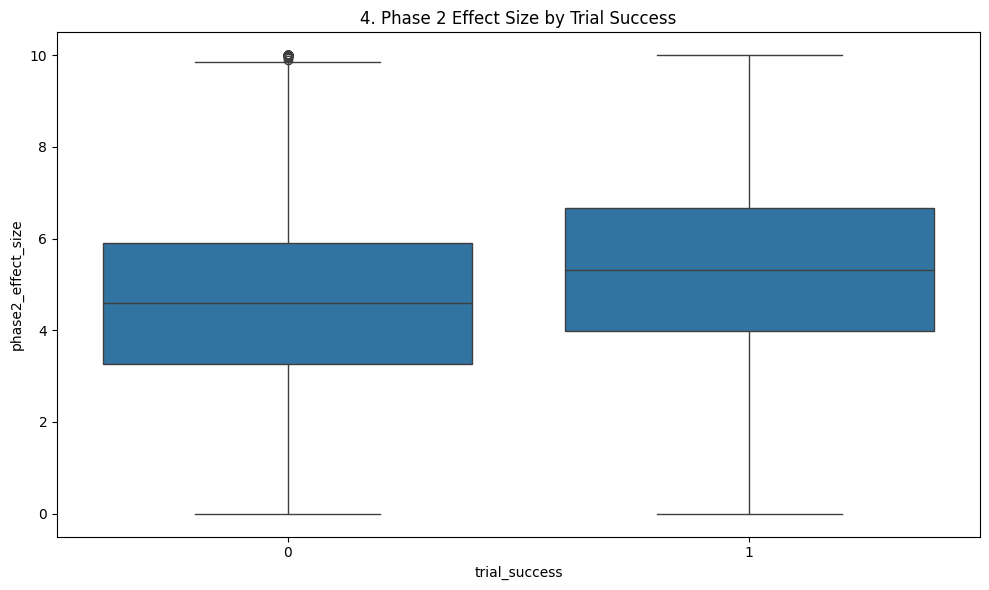

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='trial_success', y='phase2_effect_size')
plt.title(f'{plot_no}. Phase 2 Effect Size by Trial Success')
show_fig()
plot_no += 1

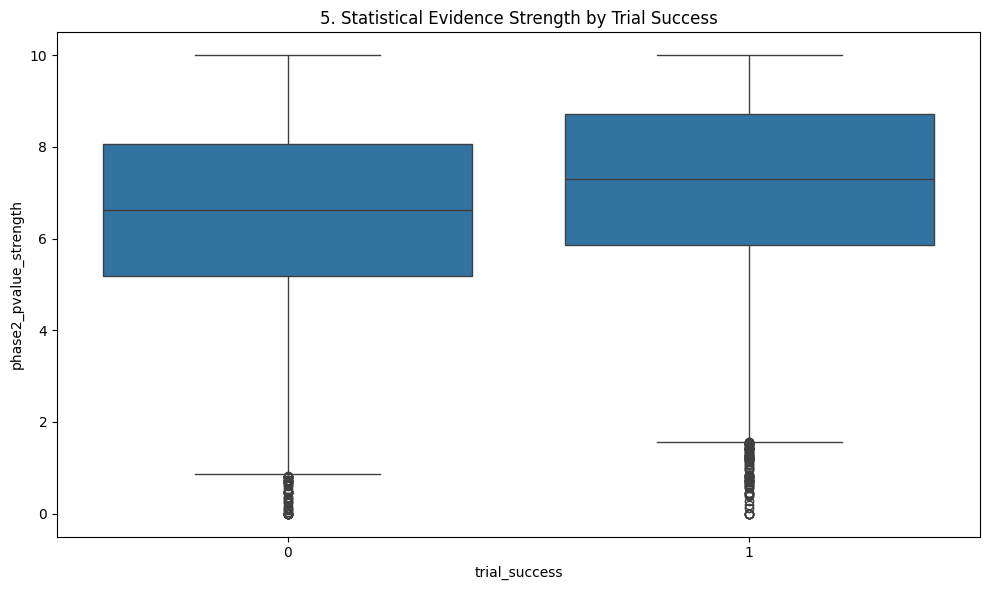

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='trial_success', y='phase2_pvalue_strength')
plt.title(f'{plot_no}. Statistical Evidence Strength by Trial Success')
show_fig()
plot_no += 1

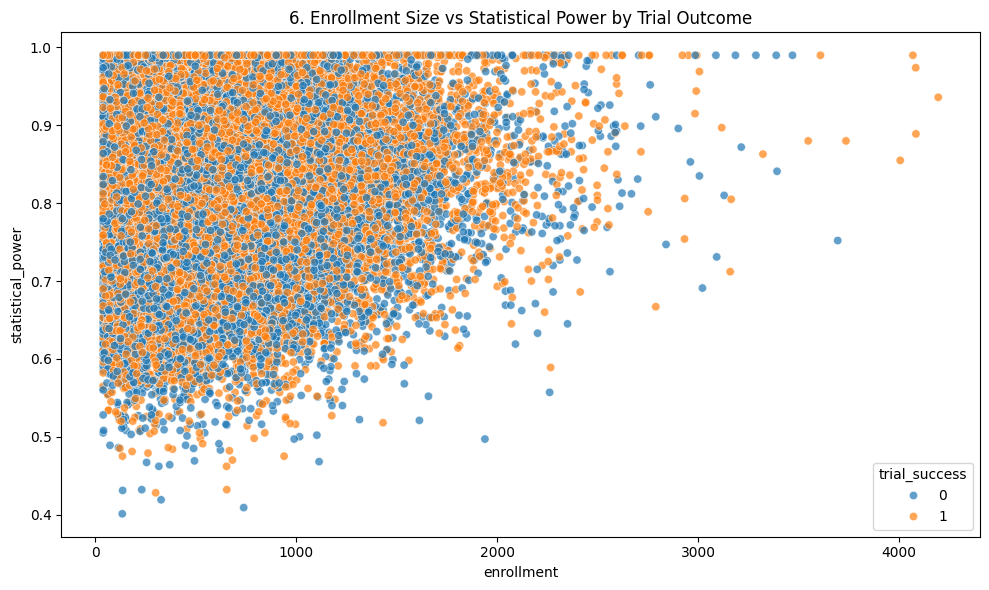

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='enrollment', y='statistical_power', hue='trial_success', alpha=0.7)
plt.title(f'{plot_no}. Enrollment Size vs Statistical Power by Trial Outcome')
show_fig()
plot_no += 1

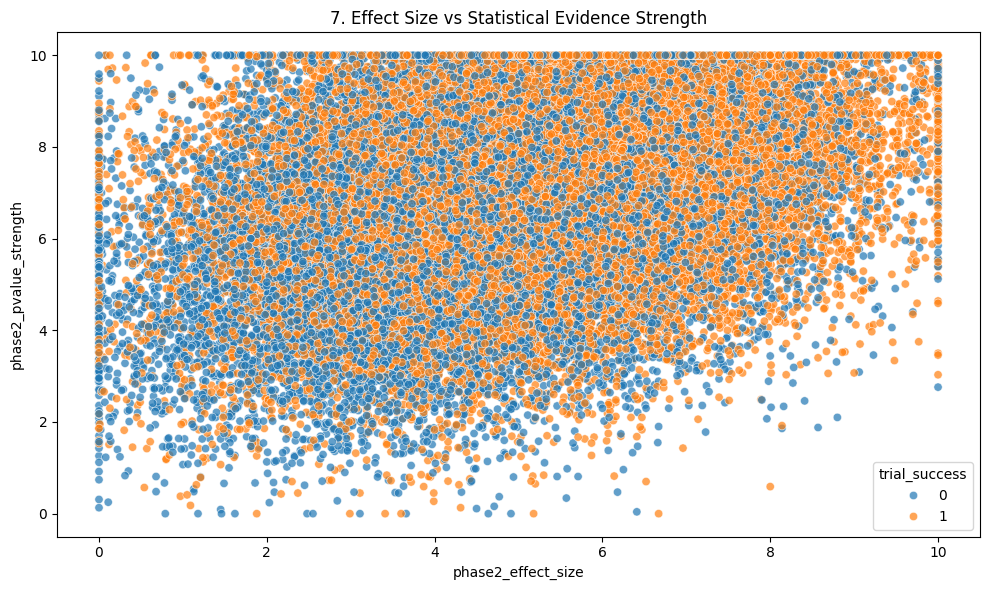

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='phase2_effect_size', y='phase2_pvalue_strength', hue='trial_success', alpha=0.7)
plt.title(f'{plot_no}. Effect Size vs Statistical Evidence Strength')
show_fig()
plot_no += 1

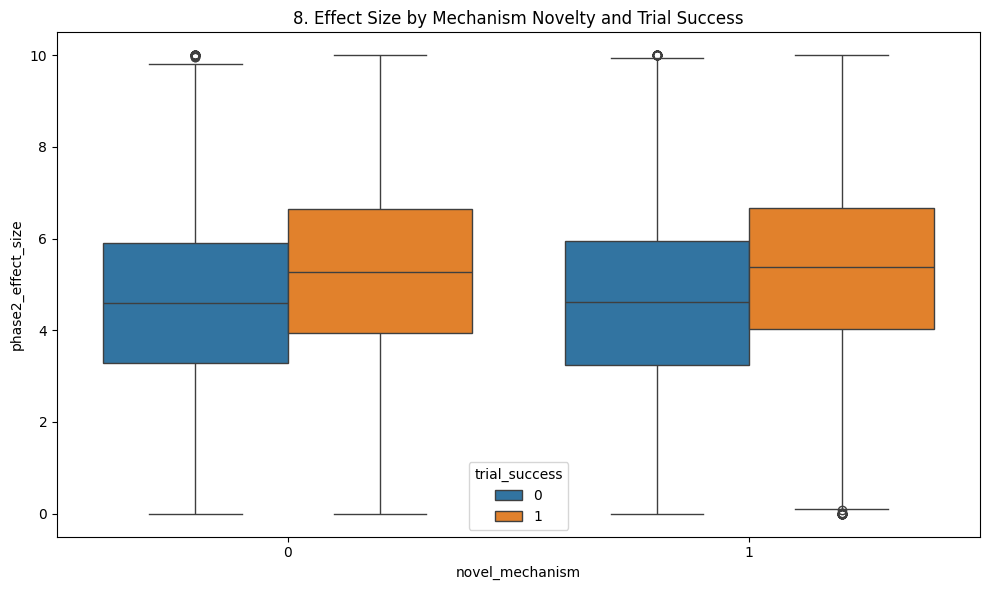

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='novel_mechanism', y='phase2_effect_size', hue='trial_success')
plt.title(f'{plot_no}. Effect Size by Mechanism Novelty and Trial Success')
show_fig()
plot_no += 1

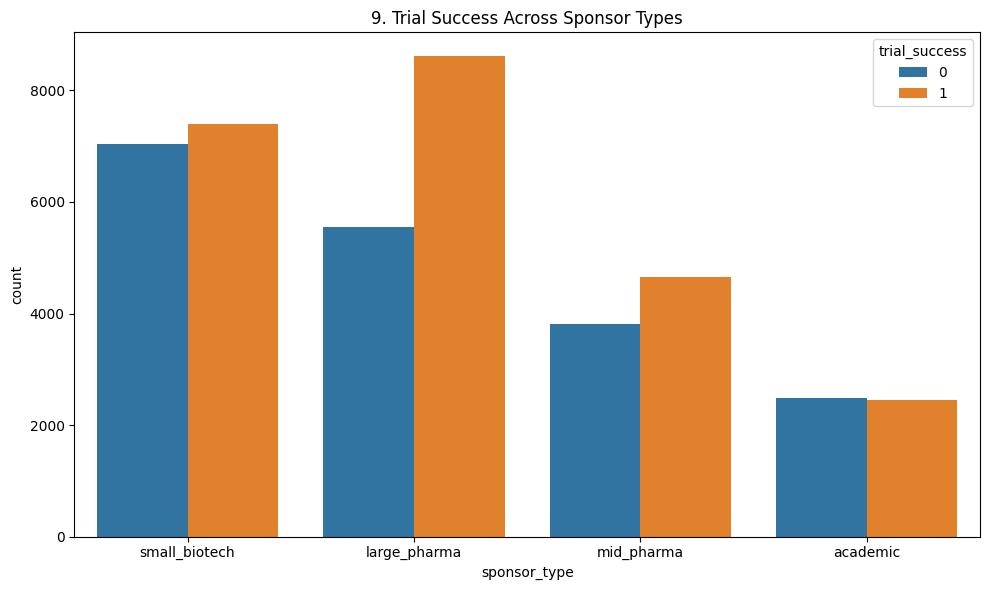

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='sponsor_type', hue='trial_success', order=df['sponsor_type'].value_counts().index)
plt.title(f'{plot_no}. Trial Success Across Sponsor Types')
show_fig()
plot_no += 1

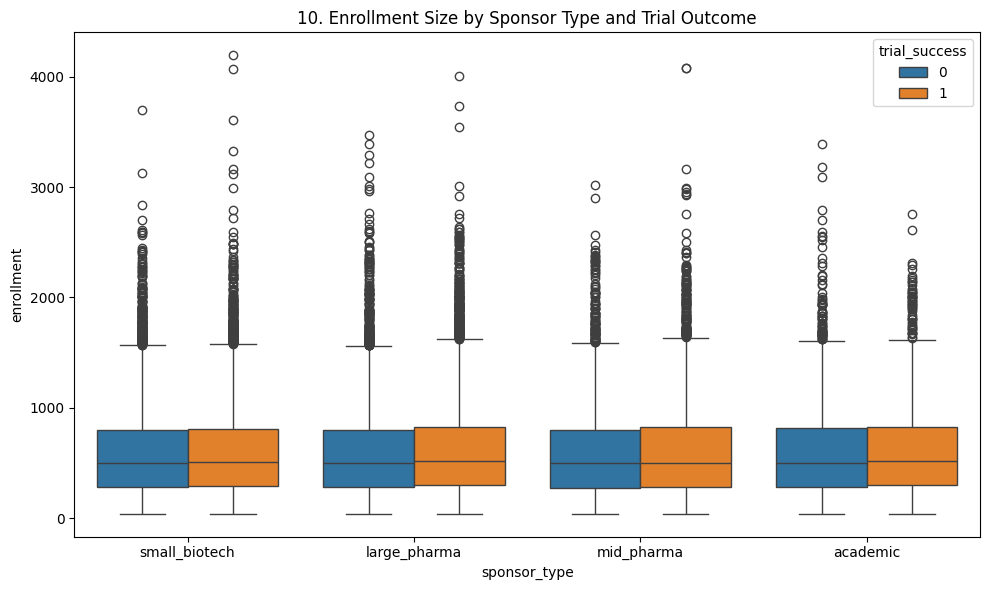

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='sponsor_type', y='enrollment', hue='trial_success', order=df['sponsor_type'].value_counts().index)
plt.title(f'{plot_no}. Enrollment Size by Sponsor Type and Trial Outcome')
show_fig()
plot_no += 1

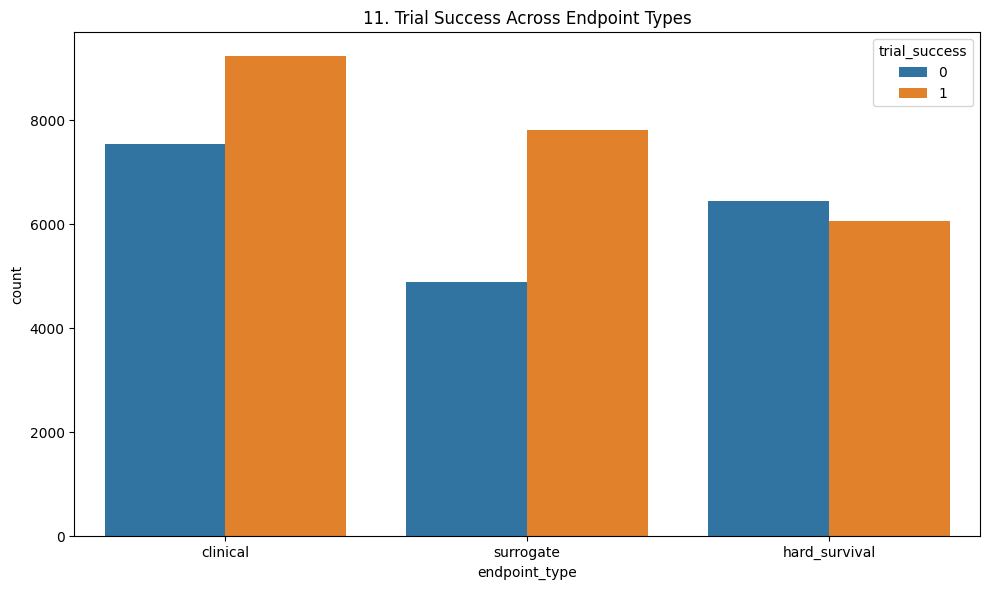

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='endpoint_type', hue='trial_success', order=df['endpoint_type'].value_counts().index)
plt.title(f'{plot_no}. Trial Success Across Endpoint Types')
show_fig()
plot_no += 1

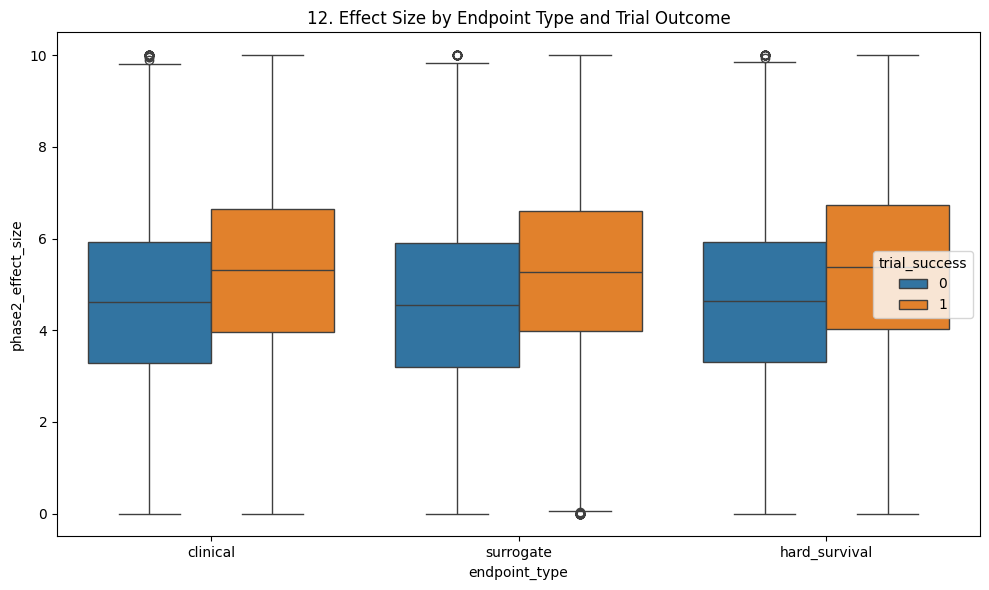

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='endpoint_type', y='phase2_effect_size', hue='trial_success', order=df['endpoint_type'].value_counts().index)
plt.title(f'{plot_no}. Effect Size by Endpoint Type and Trial Outcome')
show_fig()
plot_no += 1

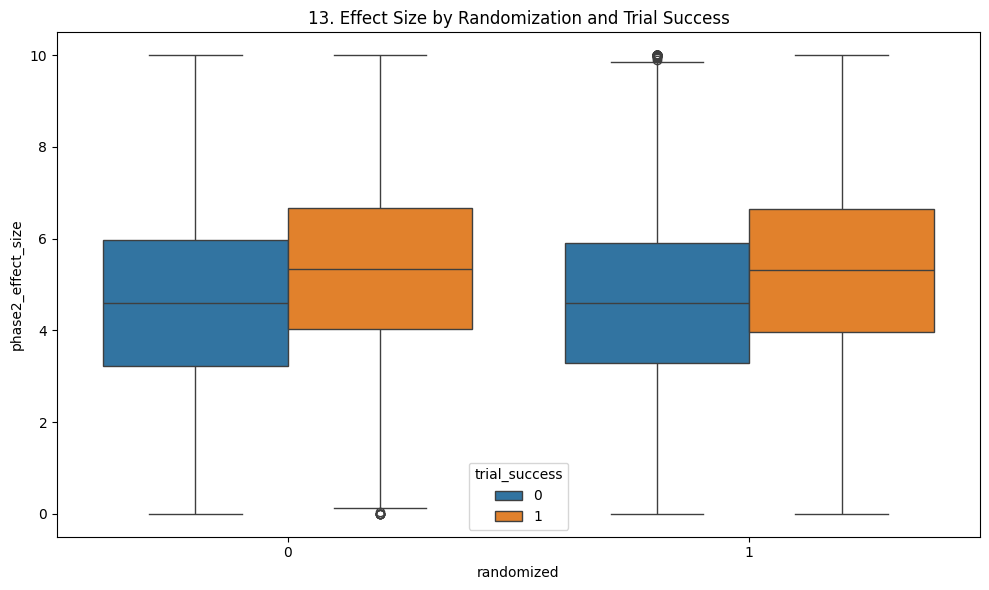

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='randomized', y='phase2_effect_size', hue='trial_success')
plt.title(f'{plot_no}. Effect Size by Randomization and Trial Success')
show_fig()
plot_no += 1

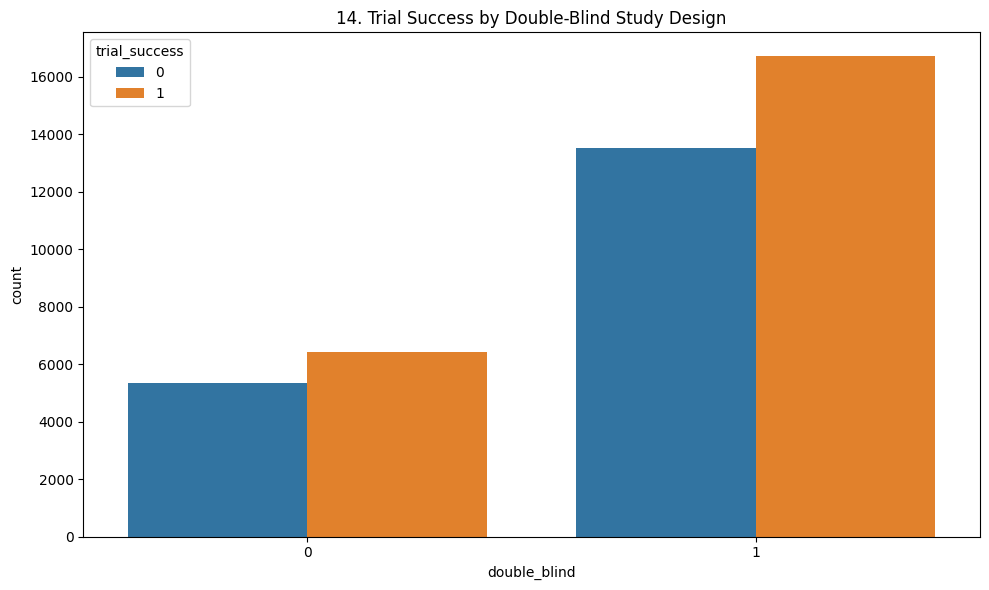

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='double_blind', hue='trial_success')
plt.title(f'{plot_no}. Trial Success by Double-Blind Study Design')
show_fig()
plot_no += 1

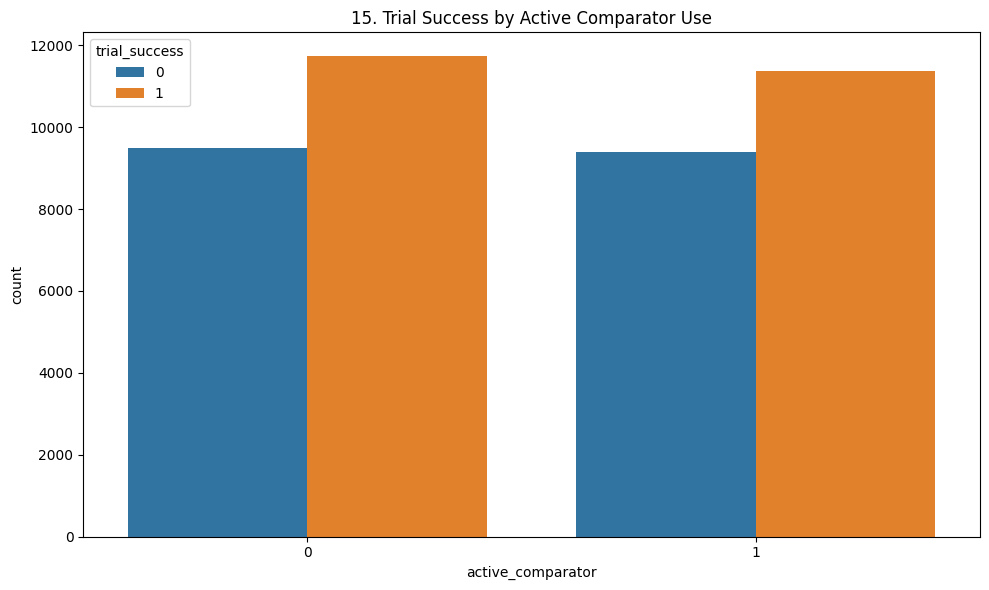

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='active_comparator', hue='trial_success')
plt.title(f'{plot_no}. Trial Success by Active Comparator Use')
show_fig()
plot_no += 1

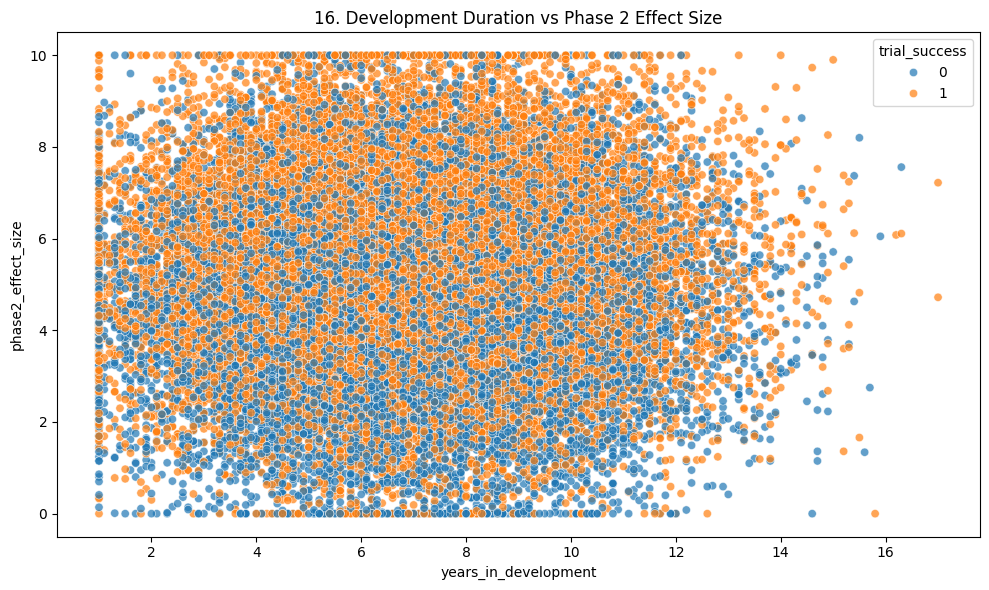

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='years_in_development', y='phase2_effect_size', hue='trial_success', alpha=0.7)
plt.title(f'{plot_no}. Development Duration vs Phase 2 Effect Size')
show_fig()
plot_no += 1

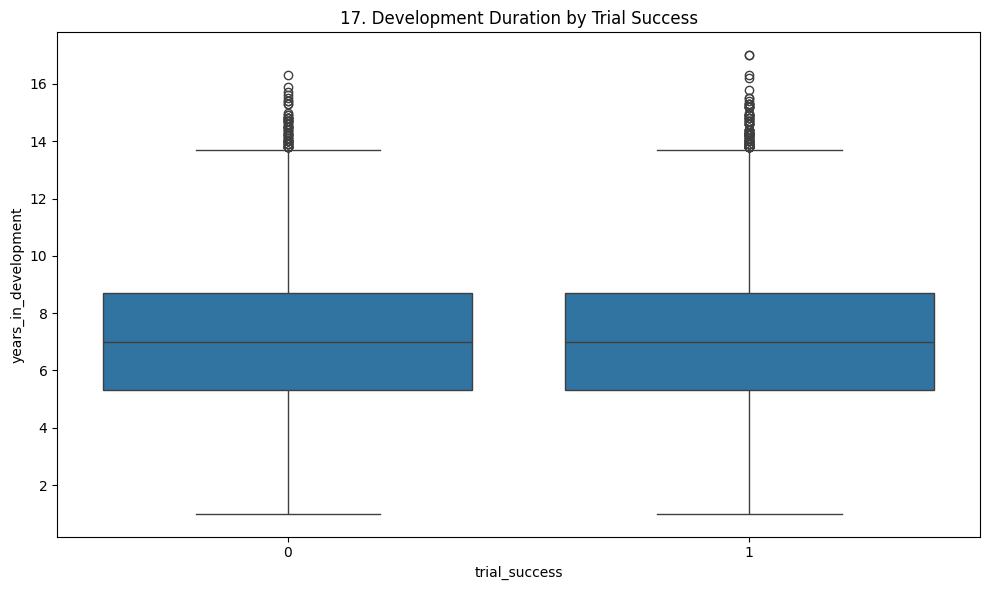

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='trial_success', y='years_in_development')
plt.title(f'{plot_no}. Development Duration by Trial Success')
show_fig()
plot_no += 1

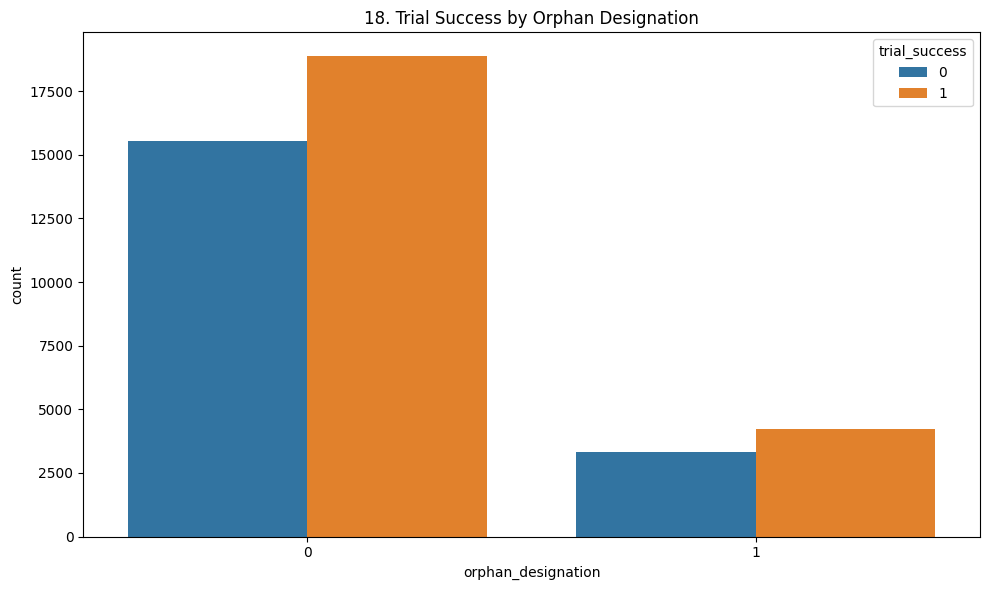

In [30]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='orphan_designation', hue='trial_success')
plt.title(f'{plot_no}. Trial Success by Orphan Designation')
show_fig()
plot_no += 1

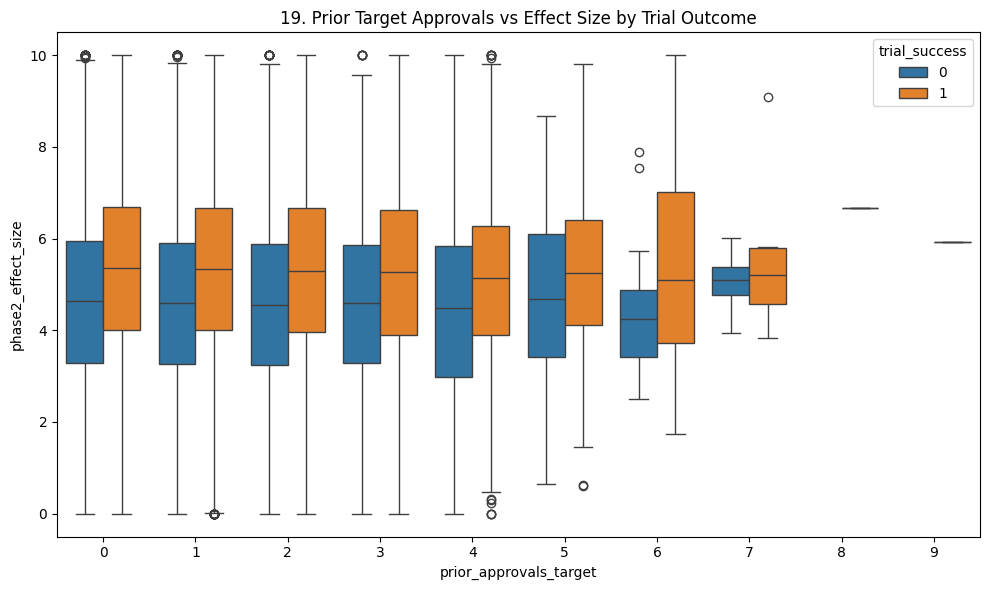

In [31]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='prior_approvals_target', y='phase2_effect_size', hue='trial_success')
plt.title(f'{plot_no}. Prior Target Approvals vs Effect Size by Trial Outcome')
show_fig()
plot_no += 1

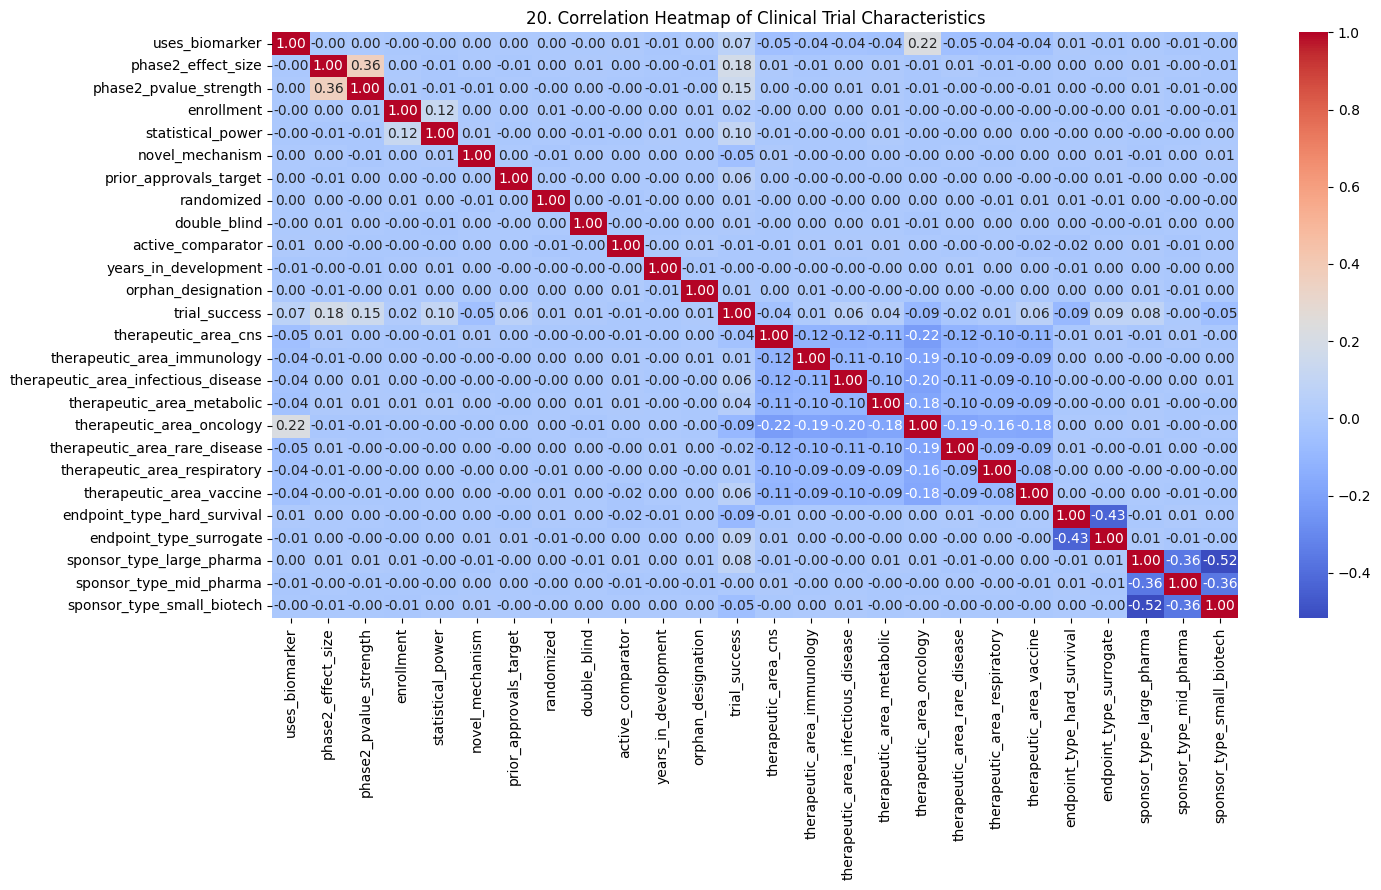

In [32]:
corr = df.drop(columns=['trial_id']).copy()
corr = pd.get_dummies(corr, drop_first=True).corr()

fig = plt.figure(figsize=(15, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Clinical Trial Characteristics')
show_fig()
plot_no += 1

# Model Training

## prepare features

In [33]:
X = df.drop(columns=['trial_id', 'trial_success']).copy()
y = df['trial_success']

## encode categorical features

In [34]:
X = pd.get_dummies(X, drop_first=True)

## fill missing values

In [35]:
X = X.fillna(X.median(numeric_only=True))
X = X.fillna(0)

## split dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## create fast gradient boosting model

In [37]:
model = HistGradientBoostingClassifier(
    max_iter=150,
    learning_rate=0.06,
    max_leaf_nodes=15,
    min_samples_leaf=10,
    l2_regularization=1.5,
    random_state=42
)

## train model

In [38]:
model.fit(X_train, y_train)

HistGradientBoostingClassifier(l2_regularization=1.5, learning_rate=0.06,
                               max_iter=150, max_leaf_nodes=15,
                               min_samples_leaf=10, random_state=42)

## make predictions

In [39]:
y_pred = model.predict(X_test)

## calculate accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 63.48%


## create confusion matrix

In [41]:
cm = confusion_matrix(y_test, y_pred)

## plot confusion matrix

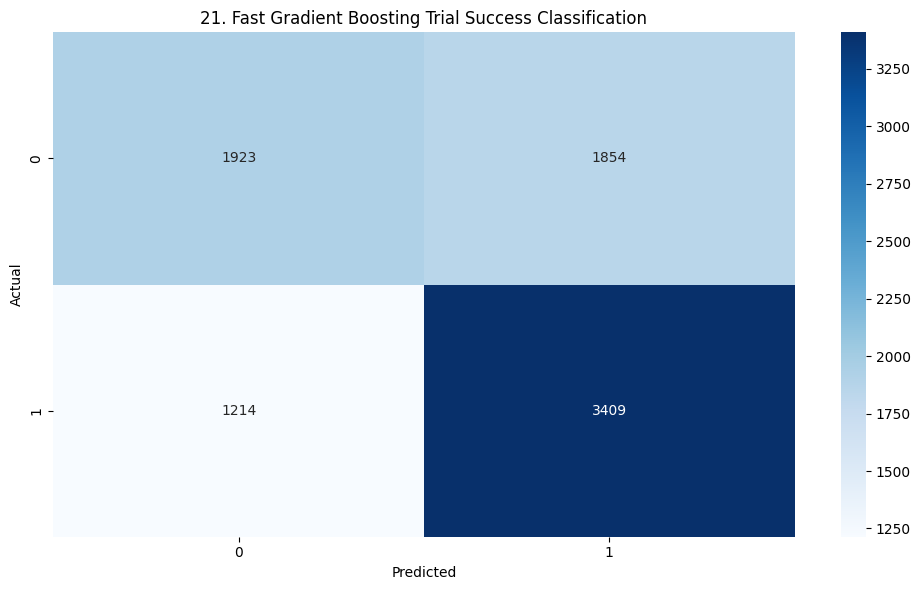

In [42]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'{plot_no}. Fast Gradient Boosting Trial Success Classification')
show_fig()
plot_no += 1